In [1]:
from google.colab import files

uploaded = files.upload()

Saving customer_segments.csv to customer_segments.csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("Ishan Adhikari")
df = pd.read_csv("customer_segments.csv")
print(df.head())


Ishan Adhikari
  CustomerID  AnnualIncome_k  SpendingScore
0       C001            85.3           78.1
1       C002            24.1           18.5
2       C003            56.7           46.8
3       C004            44.4           32.5
4       C005            84.9           75.3


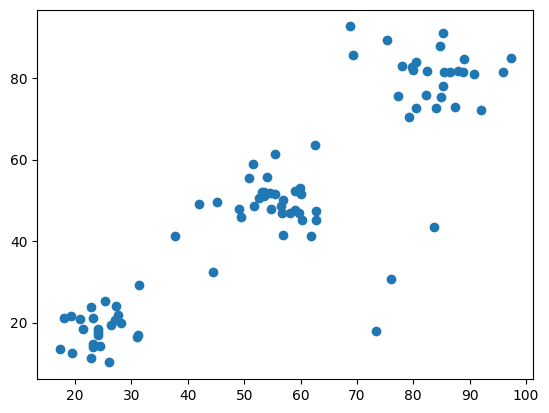

In [5]:
import matplotlib.pyplot as plt

plt.scatter(df["AnnualIncome_k"], df["SpendingScore"])
plt.show()

Ishan Adhikari


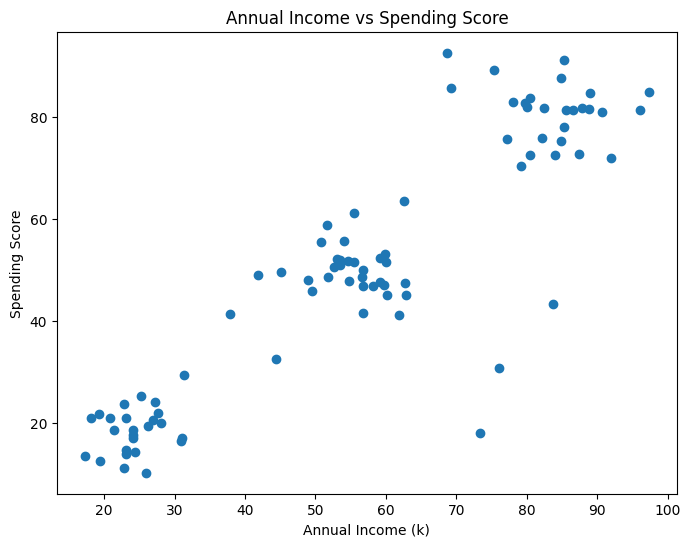

In [7]:
plt.figure(figsize=(8, 6))
print("Ishan Adhikari")

plt.scatter(df["AnnualIncome_k"], df["SpendingScore"])

plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income (k)")
plt.ylabel("Spending Score")

plt.show()

In [9]:
from sklearn.preprocessing import StandardScaler
X = df[["AnnualIncome_k", "SpendingScore"]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Ishan Adhikari")
print(X_scaled[:5])


Ishan Adhikari
[[ 1.24220867  1.14184273]
 [-1.32683208 -1.25298142]
 [ 0.04164388 -0.11584176]
 [-0.47468294 -0.69043883]
 [ 1.22541755  1.02933421]]


Ishan Adhikari
Cluster Labels:
[ 0  1  2 -1  0  0  2  2  1  2  1  2  0  0  0  2  0  1 -1  1  2  1  1  1
  1  1  2  0  2  1  0 -1  1  0  0  0  2  2  1  0  2  0  2  2  0  2  1  0
  1  2  0  2  0 -1  2  0  2  2  2  1  1  1  2  1  2  0  0  2  0  1  2  1
  2  0  2  1  2  0  2  1  1  2  0  0  0  2  2  1]
Number of clusters: 3
Number of noise points: 4


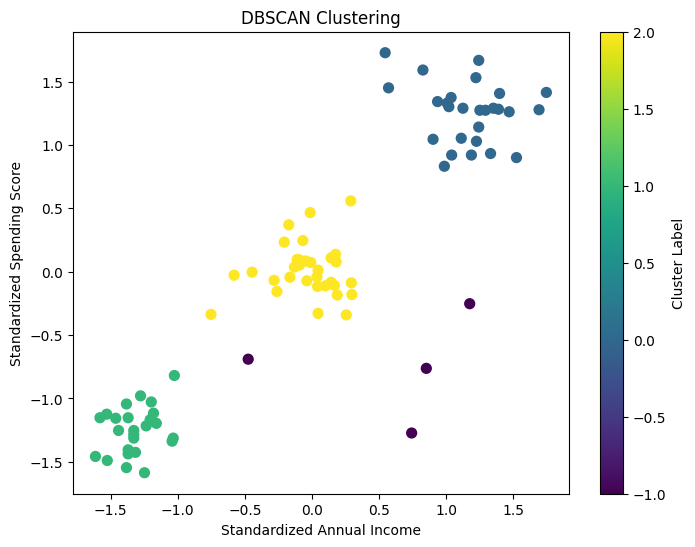

In [11]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

# Apply DBSCAN
dbscan = DBSCAN(eps=0.4, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)
print("Ishan Adhikari")
# Display cluster labels
print("Cluster Labels:")
print(dbscan_labels)

# Number of clusters (excluding noise)
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)

# Number of noise points
n_noise = list(dbscan_labels).count(-1)

print("Number of clusters:", n_clusters)
print("Number of noise points:", n_noise)

# Visualize the clusters
plt.figure(figsize=(8,6))
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=dbscan_labels,
    cmap="viridis",
    s=50
)

plt.title("DBSCAN Clustering")
plt.xlabel("Standardized Annual Income")
plt.ylabel("Standardized Spending Score")
plt.colorbar(label="Cluster Label")
plt.show()

Ishan Adhikari


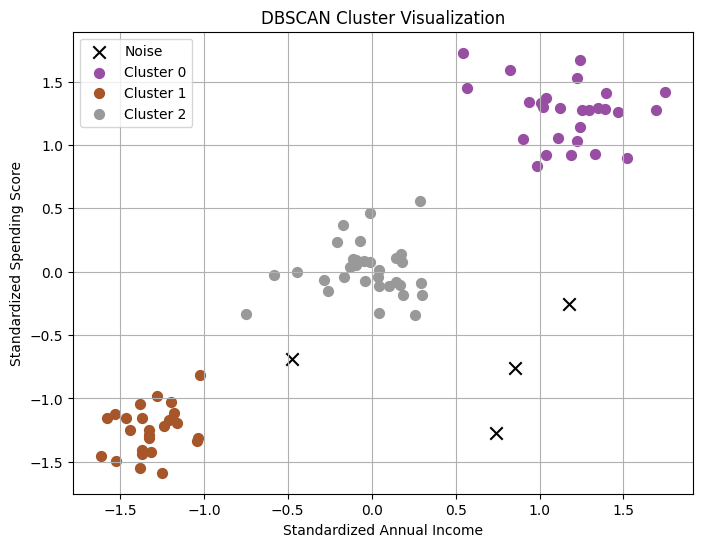

In [13]:
import matplotlib.pyplot as plt
import numpy as np
print("Ishan Adhikari")

# Unique cluster labels
labels = np.unique(dbscan_labels)

# Define colors for clusters
colors = plt.cm.Set1(np.linspace(0, 1, len(labels)))

plt.figure(figsize=(8, 6))

for label, color in zip(labels, colors):
    if label == -1:
        # Plot noise points
        plt.scatter(
            X_scaled[dbscan_labels == label, 0],
            X_scaled[dbscan_labels == label, 1],
            c='black',
            marker='x',
            s=80,
            label='Noise'
        )
    else:
        # Plot cluster points
        plt.scatter(
            X_scaled[dbscan_labels == label, 0],
            X_scaled[dbscan_labels == label, 1],
            color=color,
            s=50,
            label=f'Cluster {label}'
        )

plt.title("DBSCAN Cluster Visualization")
plt.xlabel("Standardized Annual Income")
plt.ylabel("Standardized Spending Score")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
from sklearn.cluster import DBSCAN
import pandas as pd
print("Ishan Adhikari")
# Parameter combinations to test
parameters = [
    (0.2, 3),
    (0.3, 5),
    (0.5, 5),
    (0.7, 7)
]

results = []

for eps, min_samples in parameters:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X_scaled)

    # Count clusters (excluding noise)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    # Count noise points
    n_noise = list(labels).count(-1)

    results.append([eps, min_samples, n_clusters, n_noise])

# Create results table
results_df = pd.DataFrame(
    results,
    columns=["eps", "min_samples", "Number of Clusters", "Noise Points"]
)

print(results_df)

Ishan Adhikari
   eps  min_samples  Number of Clusters  Noise Points
0  0.2            3                   3            15
1  0.3            5                   3             9
2  0.5            5                   3             4
3  0.7            7                   2             3


Ishan Adhikari


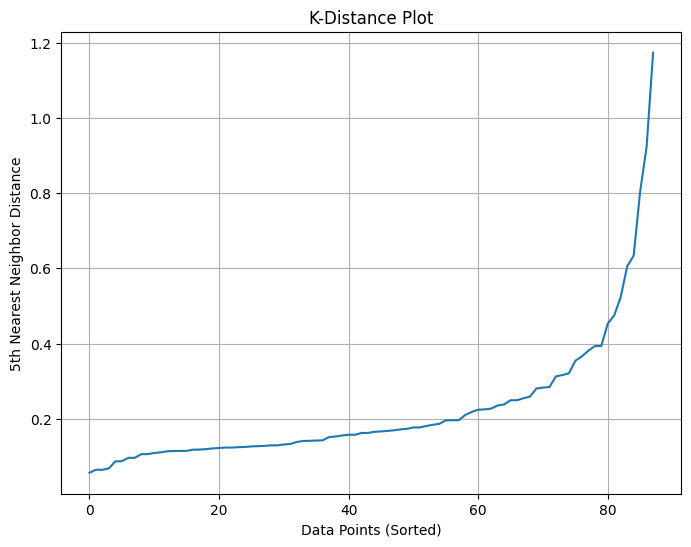

In [15]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt
print("Ishan Adhikari")
# Set k equal to min_samples (5)
k = 5

# Find the k-nearest neighbors
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_scaled)

# Compute distances
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Sort the distances to the kth nearest neighbor
k_distances = np.sort(distances[:, k-1])

# Plot the K-distance graph
plt.figure(figsize=(8,6))
plt.plot(k_distances)
plt.title("K-Distance Plot")
plt.xlabel("Data Points (Sorted)")
plt.ylabel("5th Nearest Neighbor Distance")
plt.grid(True)
plt.show()

In [17]:
# Add DBSCAN labels to the original dataframe
df["Cluster"] = dbscan_labels
print("Ishan Adhikari")
# Calculate average income and spending score for each cluster
cluster_summary = df.groupby("Cluster")[["AnnualIncome_k", "SpendingScore"]].mean()

print(cluster_summary)

Ishan Adhikari
         AnnualIncome_k  SpendingScore
Cluster                               
-1            69.375000      31.150000
 0            83.648148      80.907407
 1            24.352000      18.564000
 2            54.921875      49.965625


Ishan Adhikari
K-Means Cluster Labels:
[1 0 2 2 1 1 2 2 0 2 0 2 1 1 1 2 1 0 2 0 2 0 0 0 0 0 2 1 2 0 1 2 0 1 1 1 2
 2 0 1 2 1 2 2 1 2 0 1 0 2 1 2 1 2 2 1 2 2 2 0 0 0 2 0 2 1 1 2 1 0 2 0 2 1
 2 0 2 1 2 0 0 2 1 1 1 2 2 0]


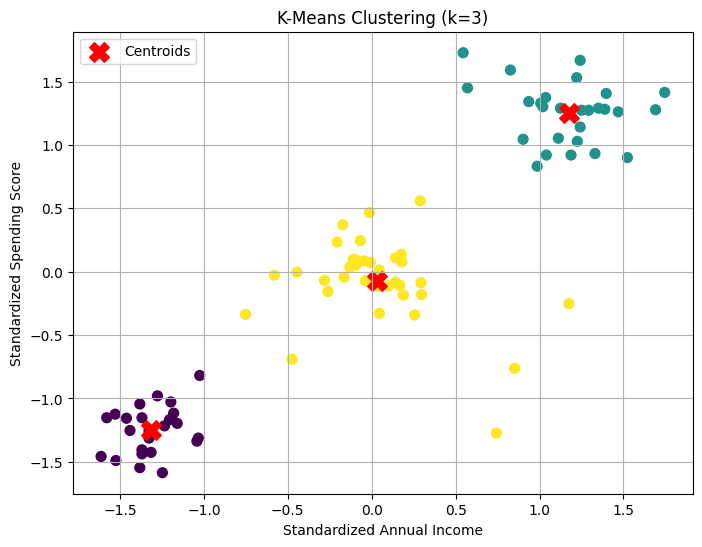

In [19]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
print("Ishan Adhikari")
# Apply K-Means with k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

kmeans_labels = kmeans.fit_predict(X_scaled)

# Display cluster labels
print("K-Means Cluster Labels:")
print(kmeans_labels)

# Visualize K-Means clusters
plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=kmeans_labels,
    cmap="viridis",
    s=50
)

# Plot cluster centers
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    color="red",
    marker="X",
    s=200,
    label="Centroids"
)

plt.title("K-Means Clustering (k=3)")
plt.xlabel("Standardized Annual Income")
plt.ylabel("Standardized Spending Score")
plt.legend()
plt.grid(True)
plt.show()